<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/Hands_On_Project_1_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install and Import Libraries**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# **Load the Dataset**

In [2]:
# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# **Explore the Dataset (EDA)**

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Data Cleaning**

In [4]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print(df.isnull().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


# **Create Age Groups**

In [5]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df['Age_Group'] = df['age'].apply(age_group)

print(df[['age', 'Age_Group']].head())

    age Age_Group
0  22.0     Adult
1  38.0     Adult
2  26.0     Adult
3  35.0     Adult
4  35.0     Adult


# **Plot 1 - Survival by Gender**

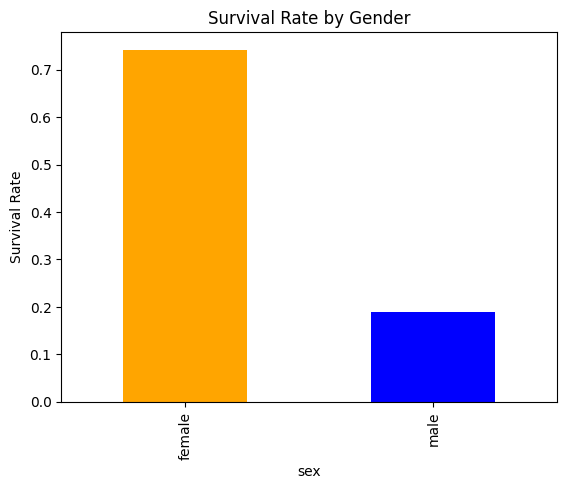

In [21]:
survival_gender = df.groupby('sex')['survived'].mean()

survival_gender.plot(
    kind='bar',
    color=['orange','blue']
)

plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

# **Plot 2 - Survival by Passenger Class**

/tmp/ipykernel_690/4126119127.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_class = df.groupby('class')['survived'].mean()


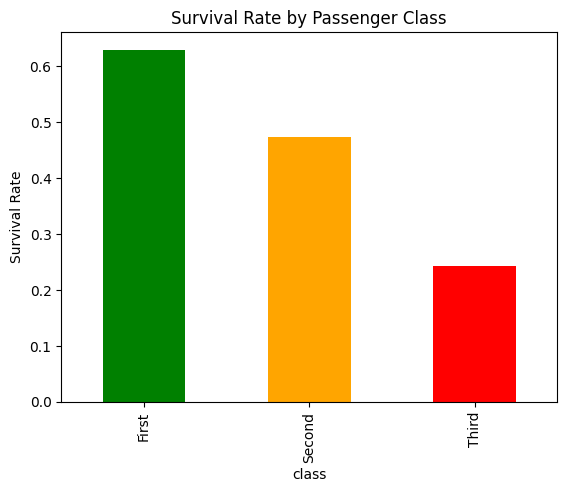

In [7]:
survival_class = df.groupby('class')['survived'].mean()

survival_class.plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

In [8]:
# Average Age by Class
average_age = df.groupby('class')['age'].mean()

print(average_age)

class
First     36.812130
Second    29.765380
Third     25.932627
Name: age, dtype: float64


/tmp/ipykernel_690/2879084243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_age = df.groupby('class')['age'].mean()


# **Filtering**

**Female survivors**

In [9]:
female_survivors = df[
    (df['sex'] == 'female') &
    (df['survived'] == 1)
]

print(len(female_survivors))

233


**Male survivors**

In [10]:
males_survivors = df[
    (df['sex'] == 'male') &
    (df['survived'] == 1)
]

print(len(males_survivors))

109


# **Grouping**

In [11]:
grouped = df.groupby(
    ['sex','class']
)['survived'].agg(['sum','mean'])

print(grouped)

               sum      mean
sex    class                
female First    91  0.968085
       Second   70  0.921053
       Third    72  0.500000
male   First    45  0.368852
       Second   17  0.157407
       Third    47  0.135447


/tmp/ipykernel_690/1252888633.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(


**Reshape With Pivot Table**

In [20]:
pivot = pd.pivot_table(
    df,
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

pivot.style.format("{:.2%}")

/tmp/ipykernel_690/1698901506.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


class,First,Second,Third
sex,,,
female,96.81%,92.11%,50.00%
male,36.89%,15.74%,13.54%


# **Merge**

In [14]:
age_info = pd.DataFrame({
    'Age_Group':['Child','Adult','Senior'],
    'Priority':['High','Normal','Medium']
})

merged_df = pd.merge(df, age_info, on='Age_Group', how='left')
merged_df[['Age_Group','Priority']].drop_duplicates()

,Age_Group,Priority
0,Adult,Normal
7,Child,High
33,Senior,Medium


# **Loop: Passengers per age group**

In [15]:
for group in df['Age_Group'].unique():
    count = len(df[df['Age_Group'] == group])
    print(group, count)


Adult 752
Child 113
Senior 26


# **Additional - Grouping**

In [16]:
# Survival Rate by Gender, Age Group
survival_rate = df.groupby(['sex', 'Age_Group', 'class'])['survived'].mean()

print(survival_rate)

sex     Age_Group  class 
female  Adult      First     0.975904
                   Second    0.906250
                   Third     0.481481
        Child      First     0.875000
                   Second    1.000000
                   Third     0.542857
        Senior     First     1.000000
                   Second         NaN
                   Third     1.000000
male    Adult      First     0.375000
                   Second    0.075269
                   Third     0.123333
        Child      First     1.000000
                   Second    0.818182
                   Third     0.232558
        Senior     First     0.142857
                   Second    0.250000
                   Third     0.000000
Name: survived, dtype: float64


/tmp/ipykernel_690/1487115957.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby(['sex', 'Age_Group', 'class'])['survived'].mean()


# **NumPy Operations**

In [17]:
ages = np.array(df['age'])

print("Mean Age:", np.mean(ages))
print("Maximum Age:", np.max(ages))
print("Minimum Age:", np.min(ages))
print("Standard Deviation:", np.std(ages))

Mean Age: 29.36158249158249
Maximum Age: 80.0
Minimum Age: 0.42
Standard Deviation: 13.012388272793666


# **Final Insights**

In [18]:
print("Total Passengers:", len(df))
print("Total Survivors:", df['survived'].sum())

print("\nSurvival Rate:")
print(round(df['survived'].mean()*100,2), "%")

Total Passengers: 891
Total Survivors: 342

Survival Rate:
38.38 %
